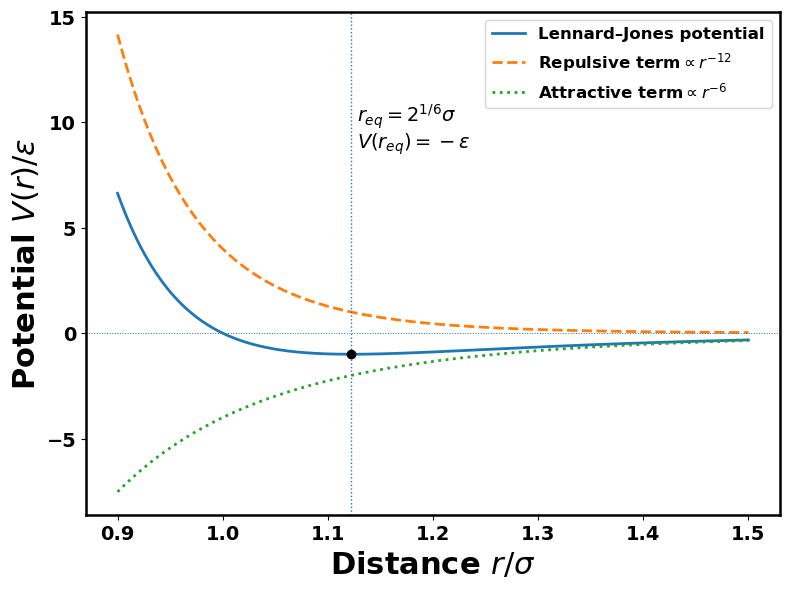

In [1]:
import numpy as np
import matplotlib.pyplot as plt

r = np.linspace(0.9, 1.5, 500)
epsilon, sigma = 1, 1

V = 4*epsilon*((sigma/r)**12 - (sigma/r)**6)
V_rep = 4*epsilon*(sigma/r)**12
V_att = -4*epsilon*(sigma/r)**6

rmin = 2**(1/6)
Vmin = -epsilon

fig, ax = plt.subplots(figsize=(8, 6))
for spine in ax.spines.values():
    spine.set_linewidth(1.8)
    
plt.plot(r, V, lw=2, label="Lennard–Jones potential")
plt.plot(r, V_rep, "--", lw=2, label=r"Repulsive term$\propto r^{-12}$")
plt.plot(r, V_att, ":", lw=2, label=r"Attractive term$\propto r^{-6}$")
plt.scatter(rmin, Vmin, color="black", zorder=5)
plt.axvline(rmin, linestyle=":", linewidth=1)

plt.axhline(0, linewidth=0.7,linestyle=":")
plt.text(rmin+0.005, 10, r"$r_{eq} = 2^{1/6}\sigma$", fontsize=14)
plt.text(rmin+0.005, 8.8, r"$V(r_{eq})=-\varepsilon$", fontsize=14)

plt.xlabel(r"Distance $r/\sigma$", fontsize=22, fontweight="bold")
plt.ylabel(r"Potential $V(r)/\varepsilon$", fontsize=22, fontweight="bold")
plt.xticks(fontsize=14, fontweight="bold")
plt.yticks(fontsize=14, fontweight="bold")

plt.legend(loc="upper right", prop={"size": 12, "weight": "bold"})
plt.tight_layout()
plt.savefig("lj_potential.pdf")
plt.show()

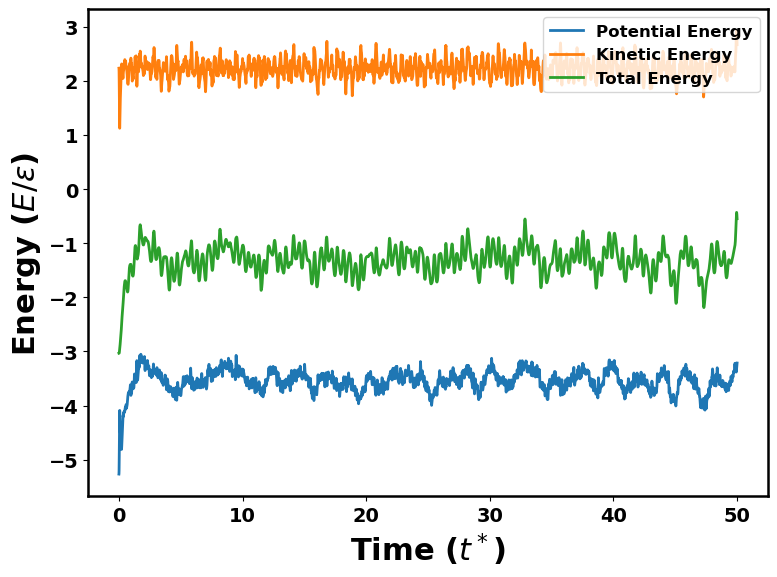

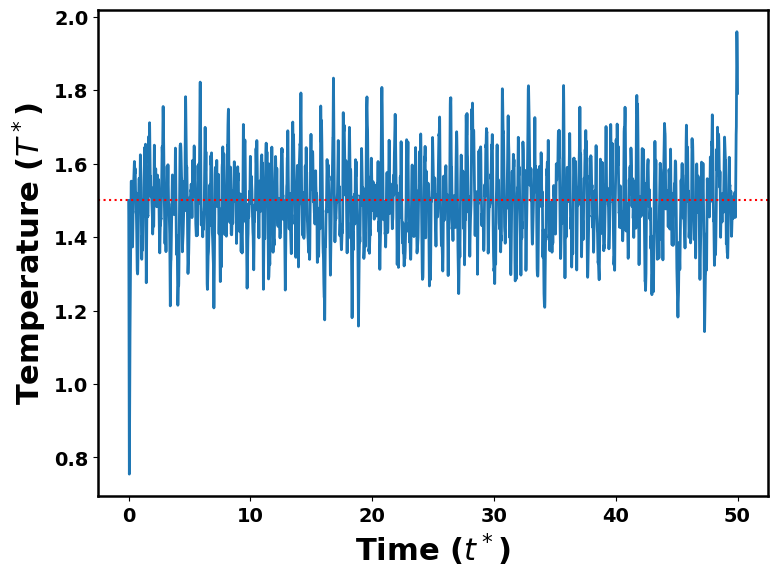

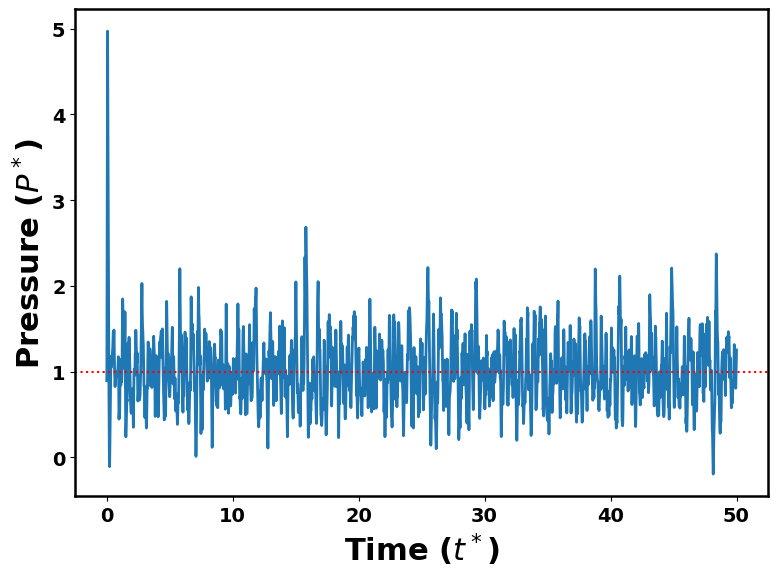

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# =========================
# User settings
# =========================
file_path = "/Users/liangze/Desktop/26 Spring/Practical Chemistry/Liquid Simulation/python/equilibration data/npt_ts0.001.csv"
fig_path = "/Users/liangze/Desktop/26 Spring/Practical Chemistry/Liquid Simulation/python/Figures"

# Set the number of atoms in your simulation
N_atoms = 125   # <-- change this to your actual number of atoms

# If you want to remove 3 translational degrees of freedom, set this to True
remove_com_motion = False

# =========================
# Read CSV
# =========================
df = pd.read_csv(file_path)

# Extract columns 0-5: Time, PotEng, KinEng, TotEng, Temp, Press
data = df.iloc[:, 0:6].copy()
data.columns = ["Time", "PotEng", "KinEng", "TotEng", "Temp", "Press"]

# Convert to numeric in case there are stray strings
for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors="coerce")

# Drop rows with missing values
data = data.dropna()

# =========================
# Global plotting style
# =========================
plt.rcParams.update({
    "font.size": 14
})

# ============================================================
# ENERGY FIGURE
# ============================================================
fig, ax = plt.subplots(figsize=(8,6))

for spine in ax.spines.values():
    spine.set_linewidth(1.8)

ax.plot(data["Time"], data["PotEng"], lw=2, label="Potential Energy")
ax.plot(data["Time"], data["KinEng"], lw=2, label="Kinetic Energy")
ax.plot(data["Time"], data["TotEng"], lw=2, label="Total Energy")

ax.set_xlabel(r"Time ($t^*$)", fontsize=22, fontweight="bold")
ax.set_ylabel(r"Energy ($E/\varepsilon$)", fontsize=22, fontweight="bold")

#ax.set_title("Energy vs Time (NPT, timestep=0.001)", fontsize=20, fontweight="bold")

ax.tick_params(axis='both', labelsize=14)
plt.xticks(fontsize=14, fontweight="bold")
plt.yticks(fontsize=14, fontweight="bold")

ax.legend(loc="upper right", prop={"size":12, "weight":"bold"})

plt.tight_layout()
plt.savefig(os.path.join(fig_path, "energy_vs_time_ts0.001.pdf"))
plt.show()


# ============================================================
# TEMPERATURE FIGURE
# ============================================================
fig, ax = plt.subplots(figsize=(8,6))

for spine in ax.spines.values():
    spine.set_linewidth(1.8)

ax.plot(data["Time"], data["Temp"], lw=2)
ax.axhline(1.5, linestyle=":", lw=1.5, color="red")

ax.set_xlabel(r"Time ($t^*$)", fontsize=22, fontweight="bold")
ax.set_ylabel(r"Temperature ($T^*$)", fontsize=22, fontweight="bold")

#ax.set_title("Temperature vs Time (NPT, timestep=0.001)", fontsize=20, fontweight="bold")

plt.xticks(fontsize=14, fontweight="bold")
plt.yticks(fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(fig_path, "temperature_vs_time_ts0.001.pdf"))
plt.show()


# ============================================================
# PRESSURE FIGURE
# ============================================================
fig, ax = plt.subplots(figsize=(8,6))

for spine in ax.spines.values():
    spine.set_linewidth(1.8)

ax.plot(data["Time"], data["Press"], lw=2)
ax.axhline(1, linestyle=":", lw=1.5, color="red")

ax.set_xlabel(r"Time ($t^*$)", fontsize=22, fontweight="bold")
ax.set_ylabel(r"Pressure ($P^*$)", fontsize=22, fontweight="bold")

#ax.set_title("Pressure vs Time (NPT, timestep=0.001)", fontsize=20, fontweight="bold")

plt.xticks(fontsize=14, fontweight="bold")
plt.yticks(fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(fig_path, "pressure_vs_time_ts0.001.pdf"))
plt.show()

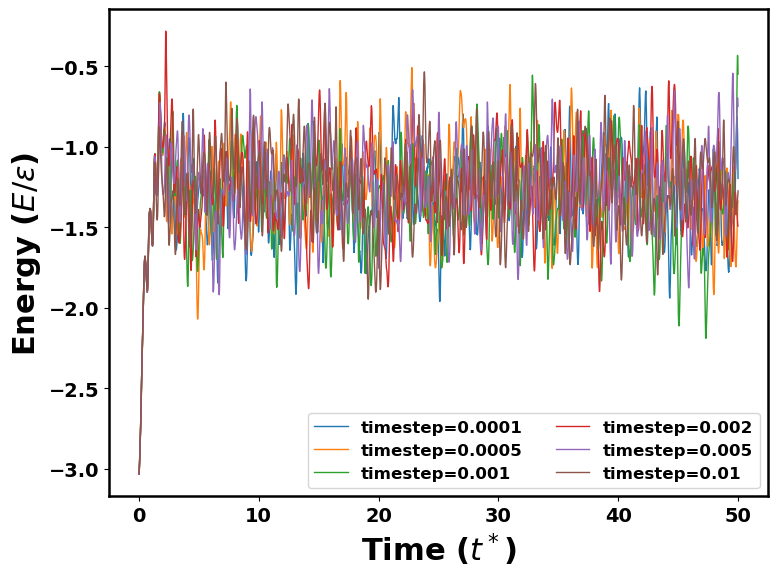

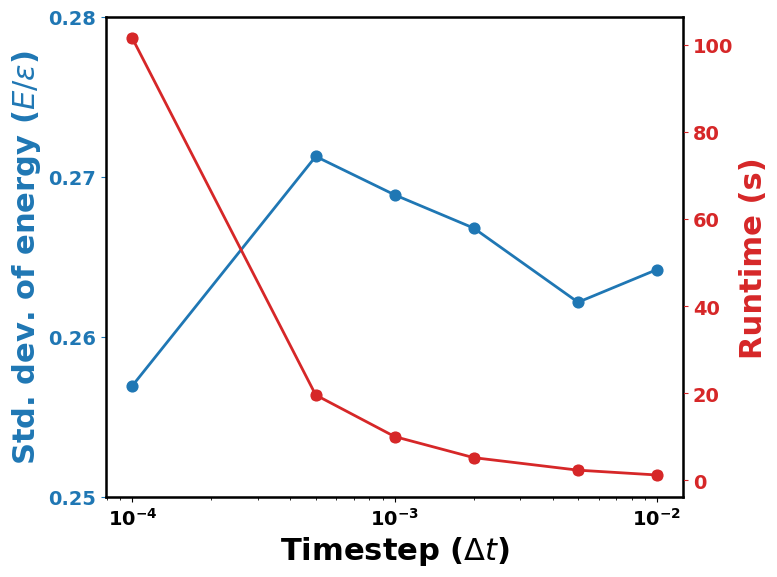

In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

# =========================
# User settings
# =========================
file_path = "/Users/liangze/Desktop/26 Spring/Practical Chemistry/Liquid Simulation/python/equilibration data/npt_energy_time_different_ts.csv"
fig_path = "/Users/liangze/Desktop/26 Spring/Practical Chemistry/Liquid Simulation/python/Figures"

# =========================
# Read CSV
# =========================
df = pd.read_csv(file_path, skiprows=1)

data = df.iloc[:, 0:12].copy()
data.columns = [
    "Time_0.0001", "TotEng_0.0001",
    "Time_0.0005", "TotEng_0.0005",
    "Time_0.001",  "TotEng_0.001",
    "Time_0.002",  "TotEng_0.002",
    "Time_0.005",  "TotEng_0.005",
    "Time_0.01",   "TotEng_0.01"
]

# Convert to numeric in case there are stray strings
for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors="coerce")

# =========================
# Global plotting style
# =========================
plt.rcParams.update({
    "font.size": 14
})

timesteps = [0.0001, 0.0005, 0.001, 0.002, 0.005, 0.01]

# ============================================================
# ENERGY FIGURE
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6))

for spine in ax.spines.values():
    spine.set_linewidth(1.8)

for ts in timesteps:
    ax.plot(
        data[f"Time_{ts}"],
        data[f"TotEng_{ts}"],
        lw=1,
        label=f"timestep={ts}"
    )

ax.set_xlabel(r"Time ($t^*$)", fontsize=22, fontweight="bold")
ax.set_ylabel(r"Energy ($E/\varepsilon$)", fontsize=22, fontweight="bold")
#ax.set_title("Energy vs Time (NPT) with different timestep", fontsize=20, fontweight="bold")

ax.tick_params(axis='both', labelsize=14)
plt.xticks(fontsize=14, fontweight="bold")
plt.yticks(fontsize=14, fontweight="bold")

ax.legend(loc="lower right", prop={"size": 12, "weight": "bold"}, ncol=2)

plt.tight_layout()
plt.savefig(os.path.join(fig_path, "energy_vs_time_different_ts.pdf"))
plt.show()

# ============================================================
# STD + RUNTIME VS TIMESTEP (DUAL AXIS FIGURE)
# ============================================================

timesteps = [0.0001, 0.0005, 0.001, 0.002, 0.005, 0.01]
loop_time = [101.453, 19.5833, 10.0399, 5.21044, 2.33439, 1.22569]

# ---- compute std ----
std_values = []
for ts in timesteps:
    series = data[f"TotEng_{ts}"].dropna()
    std_values.append(series.std())

fig, ax1 = plt.subplots(figsize=(8,6))

# axis spine style
for spine in ax1.spines.values():
    spine.set_linewidth(1.8)

# ============================================================
# LEFT AXIS (Energy fluctuation)
# ============================================================

ax1.plot(timesteps, std_values, marker="o", lw=2, color="tab:blue")
ax1.scatter(timesteps, std_values, s=60, zorder=3, color="tab:blue")

ax1.set_xlabel(r"Timestep ($\Delta t$)", fontsize=22, fontweight="bold")
ax1.set_ylabel(r"Std. dev. of energy ($E/\varepsilon$)", fontsize=22, fontweight="bold", color="tab:blue")

ax1.set_ylim(0.25, 0.28)

ax1.set_xscale("log")

ax1.tick_params(axis='both', labelsize=14)

# ============================================================
# RIGHT AXIS (Runtime)
# ============================================================

ax2 = ax1.twinx()

ax2.plot(timesteps, loop_time, marker="s", lw=2, color="tab:red")
ax2.scatter(timesteps, loop_time, s=60, zorder=3, color="tab:red")

ax2.set_ylabel("Runtime (s)", fontsize=22, fontweight="bold", color="tab:red")

# ============================================================
# Ticks + layout
# ============================================================

ax1.tick_params(axis='y', colors="tab:blue")
ax1.set_yticks([0.25, 0.26, 0.27, 0.28])
ax2.tick_params(axis='y', colors="tab:red")

for label in ax1.get_xticklabels():
    label.set_fontweight("bold")

for label in ax1.get_yticklabels():
    label.set_fontweight("bold")

for label in ax2.get_yticklabels():
    label.set_fontweight("bold")

plt.tight_layout()
plt.savefig(os.path.join(fig_path, "timestep_stability_runtime.pdf"))
plt.show()

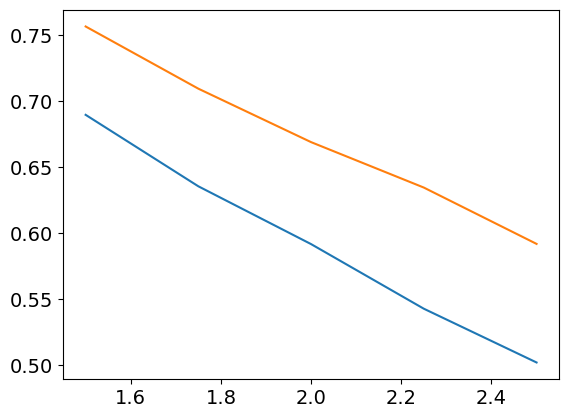

In [80]:
import numpy as np
import matplotlib.pyplot as plt

temperature = [1.5, 1.75, 2, 2.25, 2.5]

density_lowp = [0.68934012698999, 0.635232926355556, 0.591476394065121, 0.54257509400315, 0.50187655491449]
density_highp = [0.756227494818314, 0.709135779585752, 0.668674260056062, 0.634284059698216, 0.591644190373471]

plt.plot(temperature, density_lowp)
plt.plot(temperature, density_highp)
plt.show()

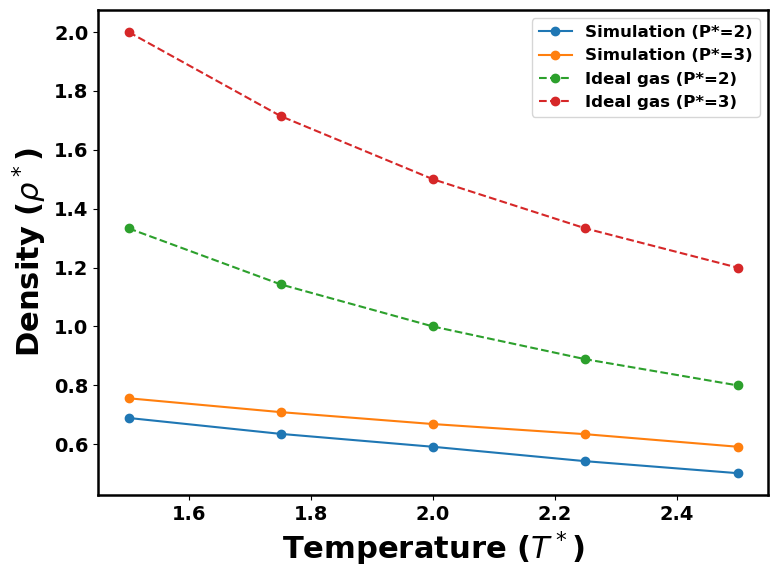

In [91]:
import numpy as np
import matplotlib.pyplot as plt
import os

fig_path = "/Users/liangze/Desktop/26 Spring/Practical Chemistry/Liquid Simulation/python/Figures"

temperature = np.array([1.5, 1.75, 2, 2.25, 2.5])

rho_low = [0.68934012698999, 0.635232926355556, 0.591476394065121, 0.54257509400315, 0.50187655491449]
rho_high = [0.756227494818314, 0.709135779585752, 0.668674260056062, 0.634284059698216, 0.591644190373471]

# Ideal gas predictions
P_low = 2
P_high = 3

rho_ideal_low = P_low / temperature
rho_ideal_high = P_high / temperature

fig, ax = plt.subplots(figsize=(8, 6))
for spine in ax.spines.values():
    spine.set_linewidth(1.8)

plt.plot(temperature, rho_low, marker="o", label="Simulation (P*=2)")
plt.plot(temperature, rho_high, marker="o", label="Simulation (P*=3)")

plt.plot(temperature, rho_ideal_low, "o--", label="Ideal gas (P*=2)")
plt.plot(temperature, rho_ideal_high, "o--", label="Ideal gas (P*=3)")

plt.xlabel(r"Temperature ($T^*$)", fontsize=22, fontweight="bold")
plt.ylabel(r"Density ($\rho^*$)", fontsize=22, fontweight="bold")

plt.xticks(fontsize=14, fontweight="bold")
plt.yticks(fontsize=14, fontweight="bold")

plt.legend(loc="upper right", prop={"size": 12, "weight": "bold"})
plt.tight_layout()
plt.savefig(os.path.join(fig_path, "density_vs_temperature_pressure.pdf"))
plt.show()

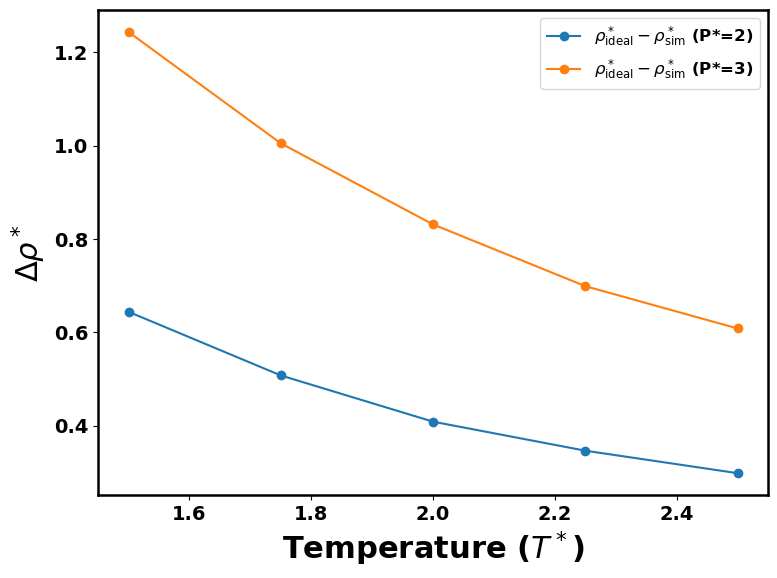

In [97]:
rho_diff_low = rho_ideal_low-rho_low
rho_diff_high = rho_ideal_high-rho_high

fig, ax = plt.subplots(figsize=(8, 6))
for spine in ax.spines.values():
    spine.set_linewidth(1.8)

plt.plot(temperature, rho_diff_low, marker="o", label=r"$\rho^*_{\mathrm{ideal}}-\rho^*_{\mathrm{sim}}$ (P*=2)")
plt.plot(temperature, rho_diff_high, marker="o", label=r"$\rho^*_{\mathrm{ideal}}-\rho^*_{\mathrm{sim}}$ (P*=3)")

plt.xlabel(r"Temperature ($T^*$)", fontsize=22, fontweight="bold")
plt.ylabel(r"$\Delta \rho^*$", fontsize=22, fontweight="bold")

plt.xticks(fontsize=14, fontweight="bold")
plt.yticks(fontsize=14, fontweight="bold")

plt.legend(loc="upper right", prop={"size": 12, "weight": "bold"})
plt.tight_layout()
plt.savefig(os.path.join(fig_path, "density_diff_vs_temperature_pressure.pdf"))
plt.show()

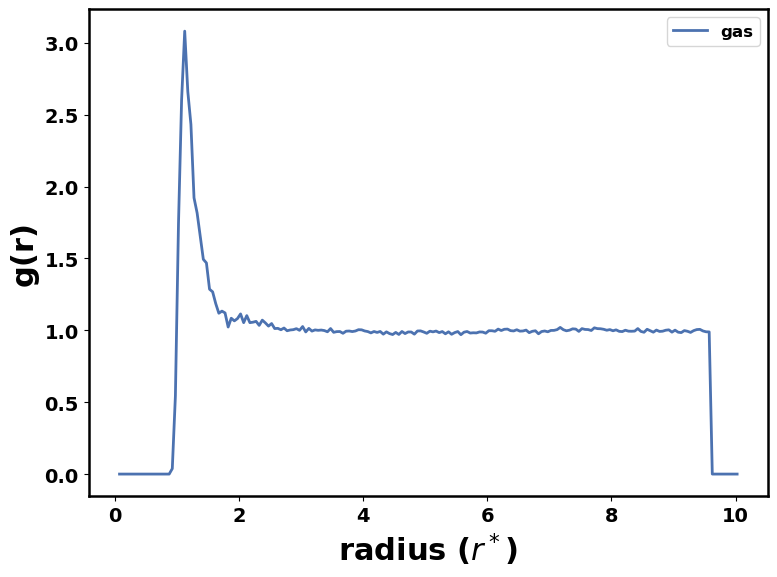

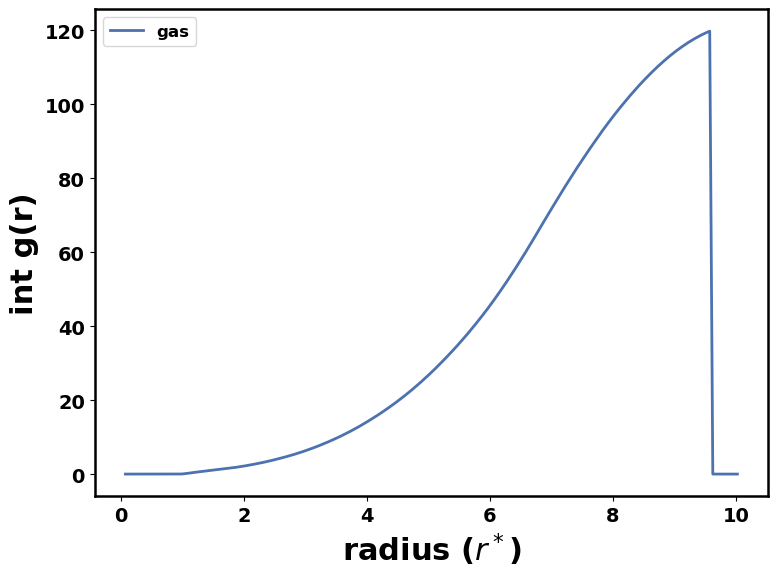

In [133]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

# =========================
# User settings
# =========================
file_path = "/Users/liangze/Desktop/26 Spring/Practical Chemistry/Liquid Simulation/python/rdf data/rdf_gas.txt"
fig_path = "/Users/liangze/Desktop/26 Spring/Practical Chemistry/Liquid Simulation/python/Figures"

# =========================
# Read CSV
# =========================
df = pd.read_csv(file_path, delim_whitespace=True)

data = df.iloc[:, 0:3].copy()
data.columns = [
    "r", "g(r)", "int g(r)"
]

# Convert to numeric in case there are stray strings
for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors="coerce")

# =========================
# Global plotting style
# =========================
plt.rcParams.update({
    "font.size": 14
})

# ============================================================
# g(r) FIGURE
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6))

for spine in ax.spines.values():
    spine.set_linewidth(1.8)

ax.plot(data["r"],
        data["g(r)"],
        lw=2,
        label="gas",
        color="#4C72B0")

ax.set_xlabel(r"radius ($r^*$)", fontsize=22, fontweight="bold")
ax.set_ylabel(r"g(r)", fontsize=22, fontweight="bold")

ax.tick_params(axis='both', labelsize=14)
plt.xticks(fontsize=14, fontweight="bold")
plt.yticks(fontsize=14, fontweight="bold")

ax.legend(loc="upper right", prop={"size": 12, "weight": "bold"})

plt.tight_layout()
plt.savefig(os.path.join(fig_path, "gas_rdf.pdf"))
plt.show()

# ============================================================
# g(r) FIGURE
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6))

for spine in ax.spines.values():
    spine.set_linewidth(1.8)

ax.plot(data["r"],
        data["int g(r)"],
        lw=2,
        label="gas",
        color="#4C72B0")

ax.set_xlabel(r"radius ($r^*$)", fontsize=22, fontweight="bold")
ax.set_ylabel(r"int g(r)", fontsize=22, fontweight="bold")

ax.tick_params(axis='both', labelsize=14)
plt.xticks(fontsize=14, fontweight="bold")
plt.yticks(fontsize=14, fontweight="bold")

ax.legend(loc="upper left", prop={"size": 12, "weight": "bold"})

plt.tight_layout()
plt.savefig(os.path.join(fig_path, "gas_rdf_int.pdf"))
plt.show()

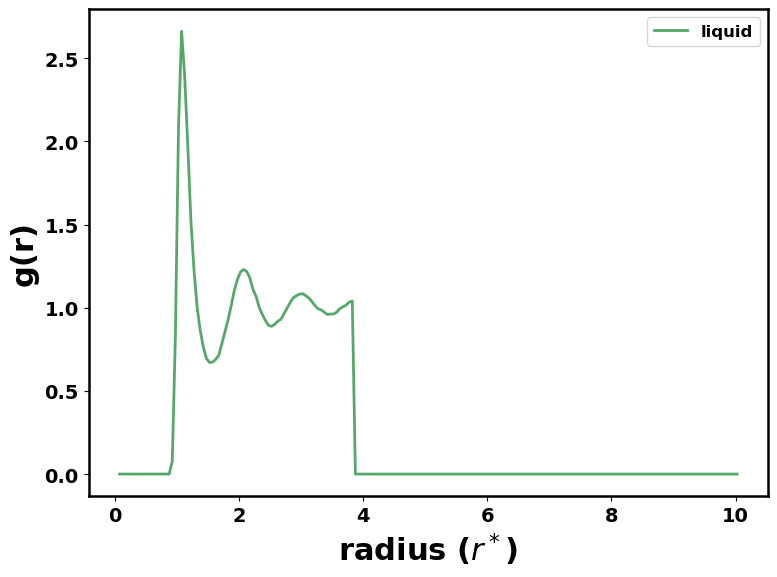

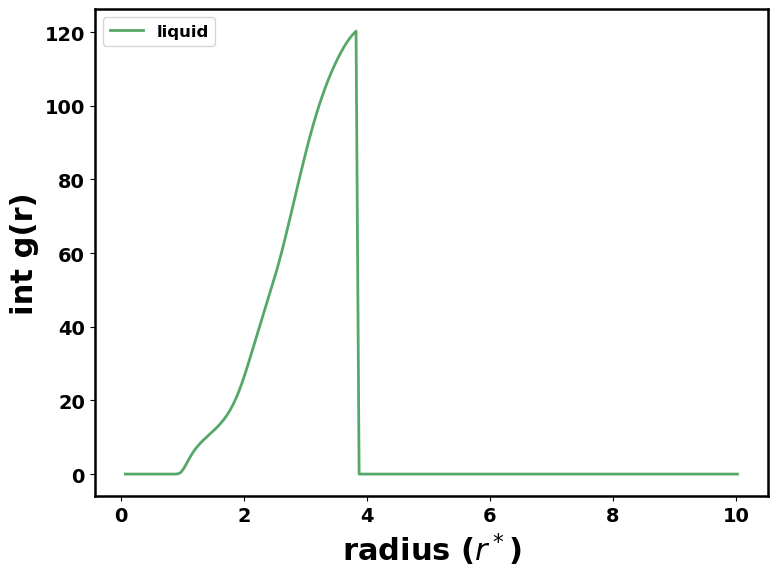

In [134]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

# =========================
# User settings
# =========================
file_path = "/Users/liangze/Desktop/26 Spring/Practical Chemistry/Liquid Simulation/python/rdf data/rdf_liq.txt"
fig_path = "/Users/liangze/Desktop/26 Spring/Practical Chemistry/Liquid Simulation/python/Figures"

# =========================
# Read CSV
# =========================
df = pd.read_csv(file_path, delim_whitespace=True)

data = df.iloc[:, 0:3].copy()
data.columns = [
    "r", "g(r)", "int g(r)"
]

# Convert to numeric in case there are stray strings
for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors="coerce")

# =========================
# Global plotting style
# =========================
plt.rcParams.update({
    "font.size": 14
})

# ============================================================
# g(r) FIGURE
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6))

for spine in ax.spines.values():
    spine.set_linewidth(1.8)

ax.plot(data["r"],
        data["g(r)"],
        lw=2,
        label="liquid",
        color="#55A868")

ax.set_xlabel(r"radius ($r^*$)", fontsize=22, fontweight="bold")
ax.set_ylabel(r"g(r)", fontsize=22, fontweight="bold")

ax.tick_params(axis='both', labelsize=14)
plt.xticks(fontsize=14, fontweight="bold")
plt.yticks(fontsize=14, fontweight="bold")

ax.legend(loc="upper right", prop={"size": 12, "weight": "bold"})

plt.tight_layout()
plt.savefig(os.path.join(fig_path, "liq_rdf.pdf"))
plt.show()

# ============================================================
# g(r) FIGURE
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6))

for spine in ax.spines.values():
    spine.set_linewidth(1.8)

ax.plot(data["r"],
        data["int g(r)"],
        lw=2,
        label="liquid",
        color="#55A868")

ax.set_xlabel(r"radius ($r^*$)", fontsize=22, fontweight="bold")
ax.set_ylabel(r"int g(r)", fontsize=22, fontweight="bold")

ax.tick_params(axis='both', labelsize=14)
plt.xticks(fontsize=14, fontweight="bold")
plt.yticks(fontsize=14, fontweight="bold")

ax.legend(loc="upper left", prop={"size": 12, "weight": "bold"})

plt.tight_layout()
plt.savefig(os.path.join(fig_path, "lid_rdf_int.pdf"))
plt.show()

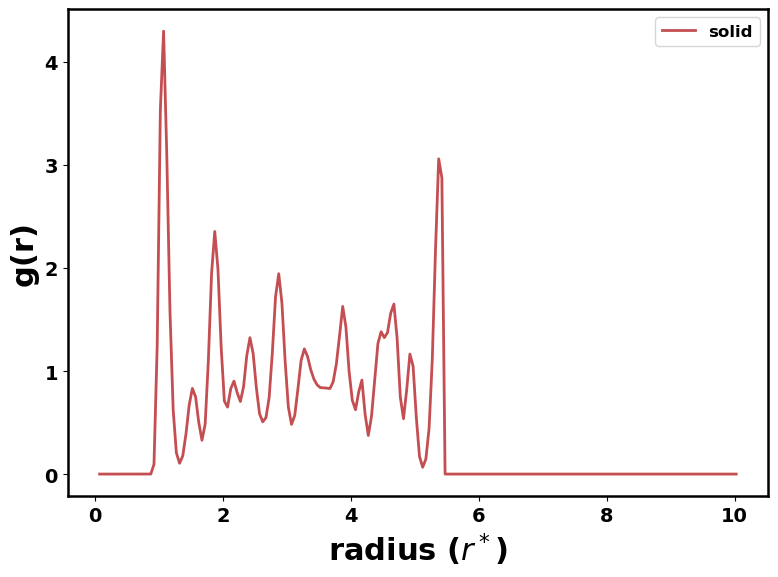

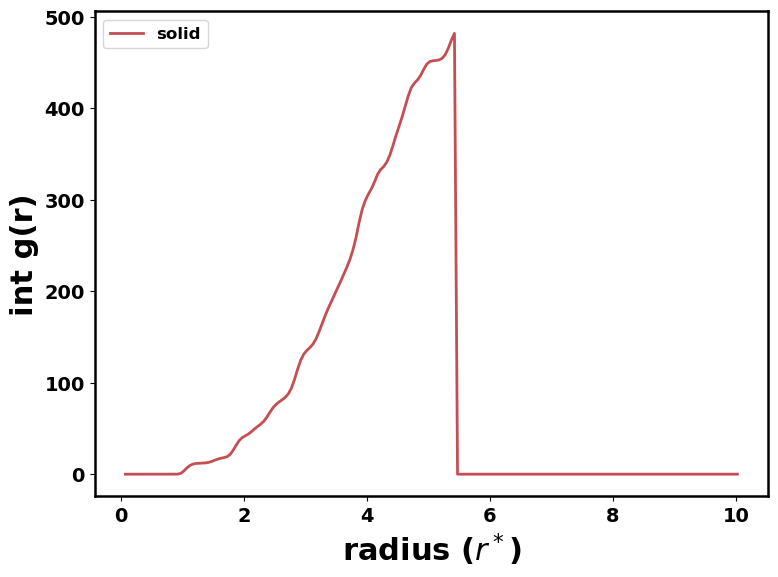

In [135]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

# =========================
# User settings
# =========================
file_path = "/Users/liangze/Desktop/26 Spring/Practical Chemistry/Liquid Simulation/python/rdf data/rdf_sol.txt"
fig_path = "/Users/liangze/Desktop/26 Spring/Practical Chemistry/Liquid Simulation/python/Figures"

# =========================
# Read CSV
# =========================
df = pd.read_csv(file_path, delim_whitespace=True)

data = df.iloc[:, 0:3].copy()
data.columns = [
    "r", "g(r)", "int g(r)"
]

# Convert to numeric in case there are stray strings
for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors="coerce")

# =========================
# Global plotting style
# =========================
plt.rcParams.update({
    "font.size": 14
})

# ============================================================
# g(r) FIGURE
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6))

for spine in ax.spines.values():
    spine.set_linewidth(1.8)

ax.plot(data["r"],
        data["g(r)"],
        lw=2,
        label="solid",
        color="#C44E52")

ax.set_xlabel(r"radius ($r^*$)", fontsize=22, fontweight="bold")
ax.set_ylabel(r"g(r)", fontsize=22, fontweight="bold")

ax.tick_params(axis='both', labelsize=14)
plt.xticks(fontsize=14, fontweight="bold")
plt.yticks(fontsize=14, fontweight="bold")

ax.legend(loc="upper right", prop={"size": 12, "weight": "bold"})

plt.tight_layout()
plt.savefig(os.path.join(fig_path, "sol_rdf.pdf"))
plt.show()

# ============================================================
# g(r) FIGURE
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6))

for spine in ax.spines.values():
    spine.set_linewidth(1.8)

ax.plot(data["r"],
        data["int g(r)"],
        lw=2,
        label="solid",
        color="#C44E52")

ax.set_xlabel(r"radius ($r^*$)", fontsize=22, fontweight="bold")
ax.set_ylabel(r"int g(r)", fontsize=22, fontweight="bold")

ax.tick_params(axis='both', labelsize=14)
plt.xticks(fontsize=14, fontweight="bold")
plt.yticks(fontsize=14, fontweight="bold")

ax.legend(loc="upper left", prop={"size": 12, "weight": "bold"})

plt.tight_layout()
plt.savefig(os.path.join(fig_path, "sol_rdf_int.pdf"))
plt.show()

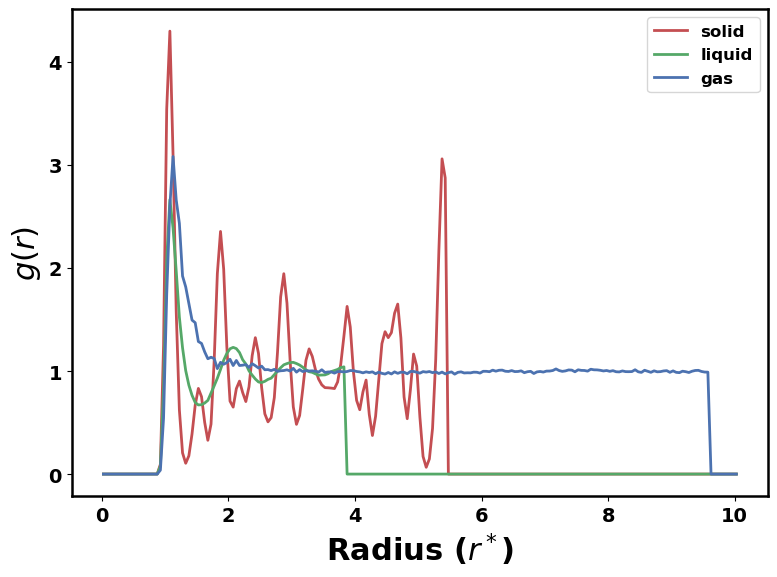

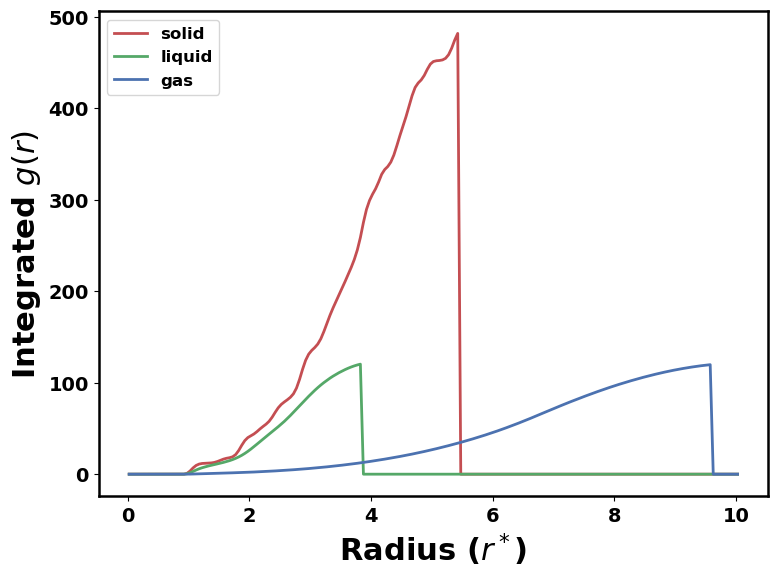

state_order = ['solid', 'liquid', 'gas']
first_min_r_list = [1.3250000000000002, 1.525, 1.675]
int_gr_at_first_min_list = [12.079401993355486, 12.0516146179402, 1.393275747508305]


In [129]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# =========================
# Paths
# =========================
data_folder = "/Users/liangze/Desktop/26 Spring/Practical Chemistry/Liquid Simulation/python/rdf data"
fig_path = "/Users/liangze/Desktop/26 Spring/Practical Chemistry/Liquid Simulation/python/Figures"

files = {
    "solid": "rdf_sol.txt",
    "liquid": "rdf_liq.txt",
    "gas": "rdf_gas.txt"
}

colors = {
    "gas": "#4C72B0",
    "liquid": "#55A868",
    "solid": "#C44E52"
}

# =========================
# Plot style
# =========================
plt.rcParams.update({"font.size": 14})

# ============================================================
# FIGURE 1: g(r)
# ============================================================
fig1, ax1 = plt.subplots(figsize=(8, 6))
for spine in ax1.spines.values():
    spine.set_linewidth(1.8)

# ============================================================
# FIGURE 2: integrated g(r)
# ============================================================
fig2, ax2 = plt.subplots(figsize=(8, 6))
for spine in ax2.spines.values():
    spine.set_linewidth(1.8)

# =========================
# Results containers
# =========================
state_order = ["solid", "liquid", "gas"]
first_min_r_list = []
int_gr_at_first_min_list = []

# =========================
# Read and plot data
# =========================
for state in state_order:
    filename = files[state]
    file_path = os.path.join(data_folder, filename)

    df = pd.read_csv(file_path, sep=r"\s+", header=None)

    data = df.iloc[:, 0:3].copy()
    data.columns = ["r", "g(r)", "int g(r)"]
    data = data.apply(pd.to_numeric, errors="coerce").dropna().reset_index(drop=True)

    # -------------------------
    # Plot curves
    # -------------------------
    ax1.plot(data["r"], data["g(r)"], lw=2, label=state, color=colors[state])
    ax2.plot(data["r"], data["int g(r)"], lw=2, label=state, color=colors[state])

    # -------------------------
    # Find first minimum after first peak
    # -------------------------
    g = data["g(r)"].values
    r = data["r"].values
    intg = data["int g(r)"].values

    # ignore the initial zero/flat region and find the first major peak
    peak_idx = g.argmax()

    # find first local minimum after that peak
    min_idx = None
    for i in range(peak_idx + 1, len(g) - 1):
        if g[i] < g[i - 1] and g[i] < g[i + 1]:
            min_idx = i
            break

    # fallback: absolute minimum after peak if no local minimum is found
    if min_idx is None:
        min_idx = peak_idx + 1 + g[peak_idx + 1:].argmin()

    first_min_r_list.append(r[min_idx])
    int_gr_at_first_min_list.append(intg[min_idx])

# =========================
# Format g(r)
# =========================
ax1.set_xlabel(r"Radius ($r^*$)", fontsize=22, fontweight="bold")
ax1.set_ylabel(r"$g(r)$", fontsize=22, fontweight="bold")

ax1.tick_params(axis="both", labelsize=14)
for label in ax1.get_xticklabels():
    label.set_fontweight("bold")
for label in ax1.get_yticklabels():
    label.set_fontweight("bold")

ax1.legend(loc="upper right", prop={"size": 12, "weight": "bold"})
fig1.tight_layout()
fig1.savefig(os.path.join(fig_path, "rdf_states.pdf"))

# =========================
# Format integrated g(r)
# =========================
ax2.set_xlabel(r"Radius ($r^*$)", fontsize=22, fontweight="bold")
ax2.set_ylabel(r"Integrated $g(r)$", fontsize=22, fontweight="bold")

ax2.tick_params(axis="both", labelsize=14)
for label in ax2.get_xticklabels():
    label.set_fontweight("bold")
for label in ax2.get_yticklabels():
    label.set_fontweight("bold")

ax2.legend(loc="upper left", prop={"size": 12, "weight": "bold"})
fig2.tight_layout()
fig2.savefig(os.path.join(fig_path, "rdf_integrated_states.pdf"))

plt.show()

# =========================
# Print results
# =========================
print("state_order =", state_order)
print("first_min_r_list =", first_min_r_list)
print("int_gr_at_first_min_list =", int_gr_at_first_min_list)

In [140]:
import pandas as pd
import os

# =========================
# Paths
# =========================
data_folder = "/Users/liangze/Desktop/26 Spring/Practical Chemistry/Liquid Simulation/python/rdf data"

files = {
    "solid": "rdf_sol.txt"
}

# =========================
# Read solid RDF data
# =========================
state = "solid"
filename = files[state]
file_path = os.path.join(data_folder, filename)

df = pd.read_csv(file_path, sep=r"\s+", header=None)

data = df.iloc[:, 0:3].copy()
data.columns = ["r", "g(r)", "int g(r)"]
data = data.apply(pd.to_numeric, errors="coerce").dropna().reset_index(drop=True)

g = data["g(r)"].values
r = data["r"].values
intg = data["int g(r)"].values

# ---- find first three peaks ----
peak_indices = []
for i in range(1, len(g) - 1):
    if g[i] > g[i - 1] and g[i] > g[i + 1]:
        peak_indices.append(i)
    if len(peak_indices) == 3:
        break

# ---- find minima after each peak ----
shell_min_indices = []
for peak in peak_indices:
    for i in range(peak + 1, len(g) - 1):
        if g[i] < g[i - 1] and g[i] < g[i + 1]:
            shell_min_indices.append(i)
            break

# ---- coordination numbers from integrated g(r) ----
shell_int = [intg[i] for i in shell_min_indices]

coord_numbers = [
    shell_int[0],
    shell_int[1] - shell_int[0],
    shell_int[2] - shell_int[1]
]

shell_positions = [r[i] for i in shell_min_indices]

print("First three shell minima r* =", shell_positions)
print("Integrated g(r) at minima =", shell_int)
print("Coordination numbers =", coord_numbers)

First three shell minima r* = [1.3250000000000002, 1.675, 2.075]
Integrated g(r) at minima = [12.079401993355486, 18.025275747508317, 43.93319601328908]
Coordination numbers = [12.079401993355486, 5.9458737541528315, 25.90792026578076]


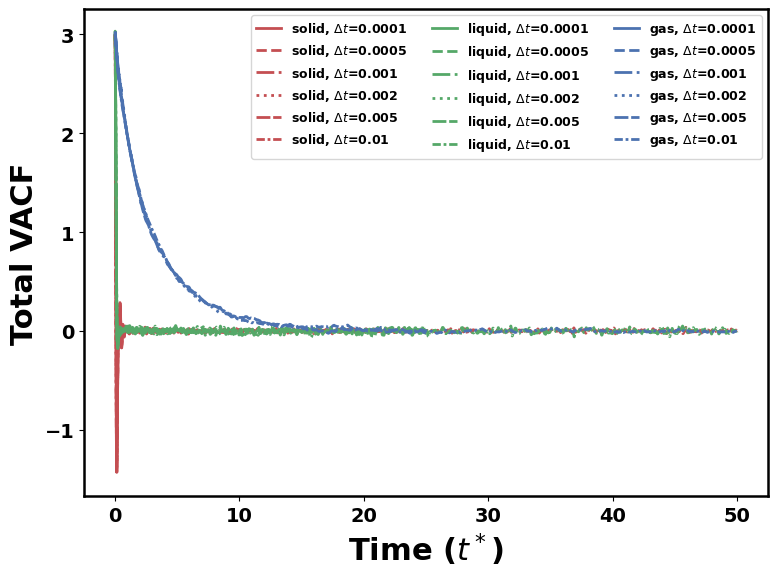

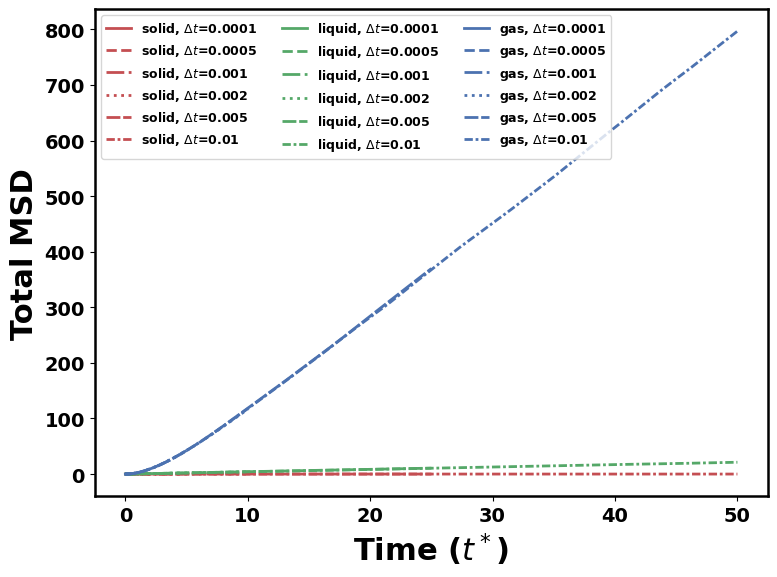

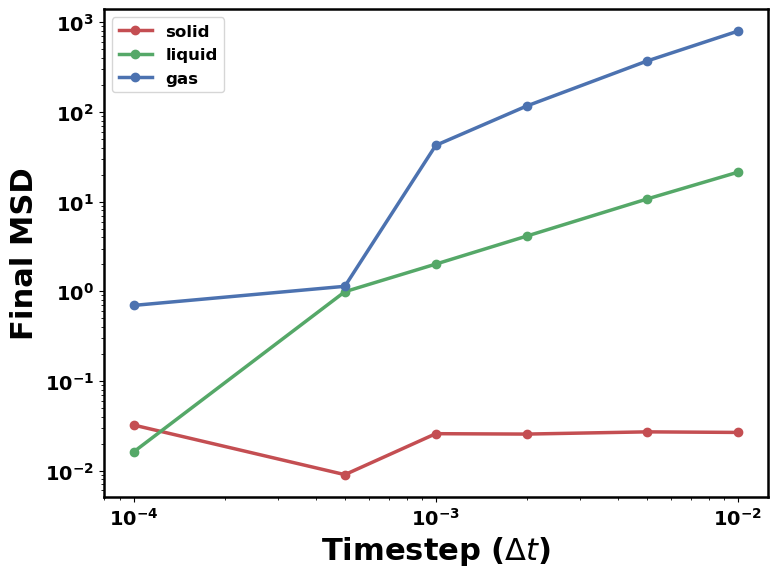

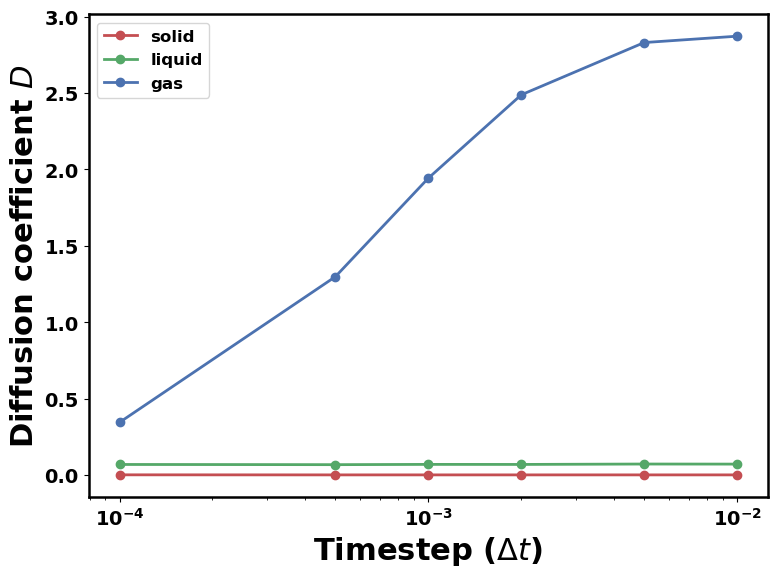

In [165]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
import numpy as np

# =========================
# Paths
# =========================
data_folder = "/Users/liangze/Desktop/26 Spring/Practical Chemistry/Liquid Simulation/python/D"
fig_path = "/Users/liangze/Desktop/26 Spring/Practical Chemistry/Liquid Simulation/python/Figures"

# =========================
# Phase labels + colours
# =========================
phase_map = {
    "sol": "solid",
    "liq": "liquid",
    "gas": "gas"
}

colors = {
    "gas": "#4C72B0",
    "liquid": "#55A868",
    "solid": "#C44E52"
}

# =========================
# Timestep order
# =========================
timestep_order = [0.0001, 0.0005, 0.001, 0.002, 0.005, 0.01]

# =========================
# Plot style
# =========================
plt.rcParams.update({"font.size": 14})

# =========================
# Read all txt files
# =========================
all_files = glob.glob(os.path.join(data_folder, "*.txt"))

# =========================
# Containers
# =========================
vacf_data = {"solid": {}, "liquid": {}, "gas": {}}
msd_data = {"solid": {}, "liquid": {}, "gas": {}}
final_msd = {"solid": {},"liquid": {},"gas": {}}
diffusion = {"solid": {}, "liquid": {}, "gas": {}}

# =========================
# Helper: convert "0p001" -> 0.001
# =========================
def parse_timestep(ts_string):
    return float(ts_string.replace("p", "."))

# =========================
# Parse and load files
# =========================
for file_path in all_files:
    filename = os.path.basename(file_path).replace(".txt", "")
    parts = filename.split("_")

    output_type = parts[0]   # output-2 or output-3
    phase_short = parts[1]   # sol, liq, gas
    ts_string = parts[2]     # 0p001

    phase = phase_map[phase_short]
    timestep = parse_timestep(ts_string)

    # Read file
    df = pd.read_csv(file_path, sep=r"\s+", header=None, skiprows=2)

    data = df.iloc[:, 0:5].copy()
    data.columns = ["step", "x", "y", "z", "total"]
    data = data.apply(pd.to_numeric, errors="coerce").dropna().reset_index(drop=True)

    # Convert step number to real reduced time
    data["time"] = data["step"] * timestep
    
    # Final MSD = last value in total column
    final_msd[phase][timestep] = data["total"].iloc[-1]

    # Store
    if output_type == "output-3":
        vacf_data[phase][timestep] = data
    elif output_type == "output-2":
        msd_data[phase][timestep] = data

# =========================
# Estimate D
# =========================

for phase in ["solid", "liquid", "gas"]:
    for ts in timestep_order:

        if ts in msd_data[phase]:

            data = msd_data[phase][ts]

            t = data["time"].values
            msd = data["total"].values

            # ---- use second half of trajectory for linear fit ----
            start = int(len(t) * 0.5)

            t_fit = t[start:]
            msd_fit = msd[start:]

            # linear fit
            slope, intercept = np.polyfit(t_fit, msd_fit, 1)

            D = slope / 6

            diffusion[phase][ts] = D

# ============================================================
# FIGURE 1: total VACF vs time
# ============================================================
fig1, ax1 = plt.subplots(figsize=(8, 6))
for spine in ax1.spines.values():
    spine.set_linewidth(1.8)

linestyles = {
    0.0001: "-",
    0.0005: "--",
    0.001: "-.",
    0.002: ":",
    0.005: (0, (5, 1)),
    0.01: (0, (3, 1, 1, 1))
}

for phase in ["solid", "liquid", "gas"]:
    for ts in timestep_order:
        if ts in vacf_data[phase]:
            data = vacf_data[phase][ts]
            ax1.plot(
                data["time"],
                data["total"],
                lw=2,
                color=colors[phase],
                linestyle=linestyles[ts],
                label=f"{phase}, $\Delta t$={ts}"
            )

ax1.set_xlabel(r"Time ($t^*$)", fontsize=22, fontweight="bold")
ax1.set_ylabel("Total VACF", fontsize=22, fontweight="bold")

ax1.tick_params(axis="both", labelsize=14)
for label in ax1.get_xticklabels():
    label.set_fontweight("bold")
for label in ax1.get_yticklabels():
    label.set_fontweight("bold")

ax1.legend(loc="upper right", prop={"size": 9, "weight": "bold"}, ncol=3)
fig1.tight_layout()
fig1.savefig(os.path.join(fig_path, "vacf_vs_time.pdf"))

# ============================================================
# FIGURE 2: total MSD vs time
# ============================================================
fig2, ax2 = plt.subplots(figsize=(8, 6))
for spine in ax2.spines.values():
    spine.set_linewidth(1.8)

for phase in ["solid", "liquid", "gas"]:
    for ts in timestep_order:
        if ts in msd_data[phase]:
            data = msd_data[phase][ts]
            ax2.plot(
                data["time"],
                data["total"],
                lw=2,
                color=colors[phase],
                linestyle=linestyles[ts],
                label=f"{phase}, $\Delta t$={ts}"
            )

ax2.set_xlabel(r"Time ($t^*$)", fontsize=22, fontweight="bold")
ax2.set_ylabel("Total MSD", fontsize=22, fontweight="bold")


ax2.tick_params(axis="both", labelsize=14)
for label in ax2.get_xticklabels():
    label.set_fontweight("bold")
for label in ax2.get_yticklabels():
    label.set_fontweight("bold")

ax2.legend(loc="upper left", prop={"size": 9, "weight": "bold"}, ncol=3)
fig2.tight_layout()
fig2.savefig(os.path.join(fig_path, "msd_vs_time.pdf"))

# ============================================================
# FIGURE 3: Final MSD vs timestep
# ============================================================
fig3, ax3 = plt.subplots(figsize=(8, 6))
for spine in ax3.spines.values():
    spine.set_linewidth(1.8)

for phase in ["solid", "liquid", "gas"]:
    x_vals = []
    y_vals = []

    for ts in timestep_order:
        if ts in final_msd[phase]:
            x_vals.append(ts)
            y_vals.append(final_msd[phase][ts])

    ax3.plot(
        x_vals,
        y_vals,
        lw=2.5,
        marker="o",
        color=colors[phase],
        label=phase
    )

ax3.set_xscale("log")

ax3.set_xlabel(r"Timestep ($\Delta t$)", fontsize=22, fontweight="bold")
ax3.set_ylabel("Final MSD", fontsize=22, fontweight="bold")
ax3.set_yscale("log")

ax3.tick_params(axis="both", labelsize=14)
for label in ax3.get_xticklabels():
    label.set_fontweight("bold")
for label in ax3.get_yticklabels():
    label.set_fontweight("bold")

ax3.legend(loc="upper left", prop={"size": 12, "weight": "bold"})
fig3.tight_layout()
fig3.savefig(os.path.join(fig_path, "final_msd_vs_timestep.pdf"))

# ============================================================
# FIGURE 4: Final MSD vs timestep
# ============================================================
fig4, ax4 = plt.subplots(figsize=(8,6))
for spine in ax4.spines.values():
    spine.set_linewidth(1.8)
    
for phase in ["solid","liquid","gas"]:
    ts_vals = []
    D_vals = []

    for ts in timestep_order:
        if ts in diffusion[phase]:
            ts_vals.append(ts)
            D_vals.append(diffusion[phase][ts])

    ax4.plot(ts_vals, D_vals, marker="o", lw=2, label=phase, color=colors[phase])

ax4.set_xscale("log")
ax4.set_xlabel(r"Timestep ($\Delta t$)", fontsize=22, fontweight="bold")
ax4.set_ylabel("Diffusion coefficient $D$", fontsize=22, fontweight="bold")

ax4.tick_params(axis="both", labelsize=14)
for label in ax4.get_xticklabels():
    label.set_fontweight("bold")
for label in ax4.get_yticklabels():
    label.set_fontweight("bold")
    
ax4.legend(loc="upper left", prop={"size": 12, "weight": "bold"})
fig4.tight_layout()
fig4.savefig(os.path.join(fig_path, "D_vs_timestep.pdf"))

plt.show()

In [169]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
import numpy as np

# =========================
# Paths
# =========================
data_folder = "/Users/liangze/Desktop/26 Spring/Practical Chemistry/Liquid Simulation/python/D_ref"
fig_path = "/Users/liangze/Desktop/26 Spring/Practical Chemistry/Liquid Simulation/python/Figures"

# =========================
# Phase labels + colours
# =========================
phase_map = {
    "sol": "solid",
    "liq": "liquid",
    "gas": "gas"
}

colors = {
    "gas": "#4C72B0",
    "liquid": "#55A868",
    "solid": "#C44E52"
}

# =========================
# Timestep order
# =========================
timestep_order = [0.0001, 0.0005, 0.001, 0.002, 0.005, 0.01]

# =========================
# Plot style
# =========================
plt.rcParams.update({"font.size": 14})

# =========================
# Read all txt files
# =========================
all_files = glob.glob(os.path.join(data_folder, "*.txt"))

# =========================
# Containers
# =========================
vacf_data = {"solid": {}, "liquid": {}, "gas": {}}
msd_data = {"solid": {}, "liquid": {}, "gas": {}}
final_msd = {"solid": {},"liquid": {},"gas": {}}
diffusion = {"solid": {}, "liquid": {}, "gas": {}}

# =========================
# Parse and load files
# =========================
for file_path in all_files:
    filename = os.path.basename(file_path).replace(".txt", "")
    parts = filename.split("_")

    output_type = parts[0]   # vacf or msd
    phase_short = parts[1]   # sol, liq, gas

    phase = phase_map[phase_short]
    timestep = parse_timestep(ts_string)

    # Read file
    df = pd.read_csv(file_path, sep=r"\s+", header=None, skiprows=2)

    data = df.iloc[:, 0:5].copy()
    data.columns = ["step", "x", "y", "z", "total"]
    data = data.apply(pd.to_numeric, errors="coerce").dropna().reset_index(drop=True)

    # Convert step number to real reduced time
    data["time"] = data["step"] * timestep
    
    # Final MSD = last value in total column
    final_msd[phase][timestep] = data["total"].iloc[-1]

    # Store
    if output_type == "vacf":
        vacf_data[phase][timestep] = data
    elif output_type == "msd":
        msd_data[phase][timestep] = data

# =========================
# Estimate D
# =========================

for phase in ["solid", "liquid", "gas"]:
    for ts in timestep_order:

        if ts in msd_data[phase]:

            data = msd_data[phase][ts]

            t = data["time"].values
            msd = data["total"].values

            # ---- use second half of trajectory for linear fit ----
            start = int(len(t) * 0.5)

            t_fit = t[start:]
            msd_fit = msd[start:]

            # linear fit
            slope, intercept = np.polyfit(t_fit, msd_fit, 1)

            D = slope / 6

            diffusion[phase][ts] = D
# =========================
# Print results
# =========================
for phase in diffusion:
    print(f"\nDiffusion coefficients for {phase}:")
    for ts in sorted(diffusion[phase]):
        print(f"D = {diffusion[phase][ts]:.5f}")


Diffusion coefficients for solid:
D = -0.00001

Diffusion coefficients for liquid:
D = 1.77657

Diffusion coefficients for gas:
D = 61.66140
